## Test Merapi cpx pairs with more mafic liquid compositions



## 1. Setup and Shared Model Pools

### Module and Data Imports

In [1]:
%matplotlib inline
from pathlib import Path
import sys

def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")

PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache"
IMAGES_DIR = PAPER_DIR / ".images"
DATA_DIR = PAPER_DIR / "data"
for _dir in (CACHE_DIR, IMAGES_DIR, DATA_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2
# %matplotlib widget
%matplotlib inline

import pandas as pd
import numpy as np
import sys
import os
import time
import importlib
import matplotlib.pyplot as plt
from aims4pt.model_tools.model_registry import  get_models_initial_pools, print_all_registered_thermobarometry, ALL_MODELS_MODULES
from aims4pt.toolkit_utils import get_file_path
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)



calculate_shap = False # make sure this to False when not needed, as it takes time and memory

timestamp = time.strftime("%Y%m%d_%H%M")
timestamp = "0260604_1550" 

In [2]:


#col names for unseen_experiments_df
cpx_names = ['SiO2_cpx', 'TiO2_cpx', 'Al2O3_cpx',
       'Fe2O3_cpx', 'Cr2O3_cpx', 'FeO_cpx', 'MnO_cpx', 'MgO_cpx', 'NiO_cpx',
       'CoO_cpx', 'CaO_cpx', 'Na2O_cpx', 'K2O_cpx', 'P2O5_cpx',]
liq_names = ['SiO2_liq', 'TiO2_liq', 'Al2O3_liq',
       'Fe2O3_liq', 'Cr2O3_liq', 'FeO_liq', 'MnO_liq', 'MgO_liq', 'NiO_liq',
       'CoO_liq', 'CaO_liq', 'Na2O_liq', 'K2O_liq', 'P2O5_liq']
P_col = 'P (kbar)'
T_col = 'T (C)'


### Initial Thermobarometry Model Pools

In [3]:
P_model_pool = get_models_initial_pools("P", "both" , False) # get all P models including cpx_only and cpx_liq
P_model_names = list(model.model_name for model in P_model_pool)
T_model_pool = get_models_initial_pools("T", "both" , False) # get all T models including cpx_only and cpx_liq
T_model_names = list(model.model_name for model in T_model_pool)


[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[skipped] Error initializing model <class 'aims4pt.model_tools.Neave_Putirka_17.Neave_Putirka_17'> with T: Pu08_eq33_T, P: eq1_P - Neave_Putirka_17 only supports pressure (P) calculations, not temperature (T) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [4]:
P_model_dict = {model.model_name: model for model in P_model_pool}
T_model_dict = {model.model_name: model for model in T_model_pool}

In [5]:
unseen_experiments_df_path = os.path.join(DATA_DIR, "independent_data_final.xlsx")
unseen_experiments_df = pd.read_excel(unseen_experiments_df_path)
cpx_unseen = unseen_experiments_df[cpx_names].copy()
liq_unseen = unseen_experiments_df[liq_names].copy()
meta_unseen = unseen_experiments_df[[P_col, T_col]].copy()

testing_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "testing"].index.tolist()
training_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "training"].index.tolist()


## 2. Loading and Preparing Merapi Data

In [6]:
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
cpx_raw_path = os.path.join(DATA_DIR, "merapi_cpx_raw.xlsx")
liq_raw_path = os.path.join(DATA_DIR, "merapi_liq_add_HPS.xlsx")
cpx_raw = pd.read_excel(cpx_raw_path)
liq_raw = pd.read_excel(liq_raw_path)
cpx_raw.columns = cpx_raw.columns.str.strip()  
liq_raw.columns = liq_raw.columns.str.strip()
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
cpx_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO',
       'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO']
# Set water content (following Scruggs and Putirka, 2018)
# Liq_Comp['H2O_Liq']=Liq_Comp['SiO2_Liq']*0.06995+0.383
cpx_raw.keys()

Index(['Sample_id', 'Eruption', 'Source', 'Rim/core', 'SiO2', 'TiO2', 'Al2O3',
       'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO', 'F', 'Cl',
       'TOTAL', '(Ca+Fe+Mg)/Si', 'cpx/opx'],
      dtype='object')

### cpx clean

Before cleaning, number of cpx samples: 530
After cpx classification, number of cpx samples: 518
After checking total, number of cpx samples: 480
After cpx stoichiometry check, number of cpx samples: 475


,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423,NaN
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768,NaN
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670,NaN
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543,NaN
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,Un 298 2010-CpxSkull-c1,2010,LI thesis,NaN,51.953300,0.382202,1.668580,8.934350,0.767469,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407,NaN
471,Un 299 2010-CpxSkull-c2,2010,LI thesis,NaN,51.316300,0.375957,1.514440,8.941050,0.749842,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019,NaN
472,Un 300 2010-CpxSkull-Rim2,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,0.331092,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198,NaN
473,Un 301 2010-CpxSkull-Rim3,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,0.298006,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423,NaN


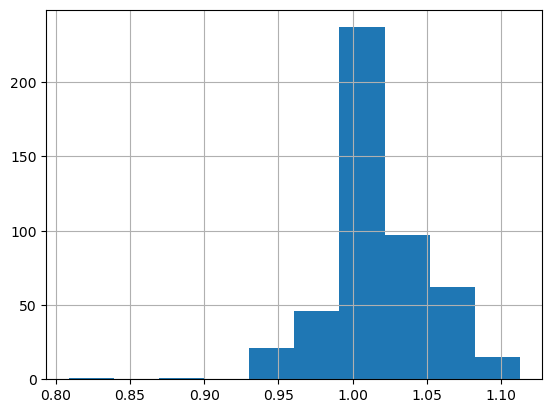

In [7]:
# clean cpx
print("Before cleaning, number of cpx samples:", len(cpx_raw))

# negative value to zero
cpx_raw[cpx_cols] = cpx_raw[cpx_cols].clip(lower=0)
# check if cpx
from aims4pt.data_tools.compositions import pyroxene_classification, cpx_stoichiometry_check

cpx_class = pyroxene_classification(cpx_raw[cpx_cols])
cpx_clean0 = cpx_raw[cpx_class=="Clinopyroxene"] # remove opx samples
print("After cpx classification, number of cpx samples:", len(cpx_clean0))
# total 

cpx_clean1 = cpx_clean0[
    (cpx_clean0["TOTAL"] > 98) & (cpx_clean0["TOTAL"] < 102)
].reset_index(drop=True)
print("After checking total, number of cpx samples:", len(cpx_clean1))

# '(Ca+Fe+Mg)/Si'
cpx_clean1['(Ca+Fe+Mg)/Si'], stio_mask = cpx_stoichiometry_check(cpx_clean1[cpx_cols])
cpx_clean1['(Ca+Fe+Mg)/Si'].hist()
cpx_clean2 = cpx_clean1[stio_mask].reset_index(drop=True)
print("After cpx stoichiometry check, number of cpx samples:", len(cpx_clean2))
cpx_clean2

In [8]:
cpx_06_input = cpx_clean2[cpx_clean2["Eruption"]==2006].reset_index(drop=True)
cpx_06_input


,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423,NaN
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768,NaN
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670,NaN
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543,NaN
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Un 159 2006pair-clB-cpx-rim-W,2006,LI thesis,NaN,51.637700,0.359146,1.598750,8.708690,0.696622,15.158300,20.371000,0.390285,NaN,0.007531,0.010138,NaN,NaN,98.938200,1.001345,NaN
166,Un 160 2006pair-clB-cpx-CORE1,2006,LI thesis,NaN,51.437700,0.409381,1.926880,8.708280,0.615156,15.110400,20.188000,0.356576,NaN,0.000000,0.020000,NaN,NaN,98.765400,1.000032,NaN
167,Un 161 2006pair-clB-cpx-CORE2,2006,LI thesis,NaN,51.680400,0.338079,1.557080,9.108510,0.726193,14.964400,20.155600,0.369271,NaN,0.000000,0.000000,NaN,NaN,98.885900,0.996929,NaN
168,Un 163 2006pair-clB-cpx-99E,2006,LI thesis,NaN,51.210300,0.355892,1.568620,8.778750,0.705213,14.858700,20.290900,0.365352,NaN,0.000000,0.002530,NaN,NaN,98.129900,1.000449,NaN


In [9]:
cpx_10_input = cpx_clean2[cpx_clean2["Eruption"]==2010].reset_index(drop=True)
cpx_10_input

,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2010-cpx1 Line 002,2010,"Li et al., 2021",rim,46.944338,1.620366,7.250910,10.177828,0.348012,12.059705,21.104987,0.414395,0.074430,NaN,NaN,0.000000,0.006035,100.001006,1.045983,NaN
1,2010-cpx1 Line 003,2010,"Li et al., 2021",rim,45.889246,1.790232,8.059587,10.460056,0.270205,11.393122,21.696318,0.392657,0.048576,NaN,NaN,0.000000,0.000000,100.000000,1.067328,NaN
2,2010-cpx1 Line 004,2010,"Li et al., 2021",rim,46.054772,1.771846,8.817550,10.425731,0.281584,10.557882,21.597609,0.461513,0.026430,NaN,NaN,0.009149,0.000000,100.004066,1.033536,NaN
3,2010-cpx1 Line 005,2010,"Li et al., 2021",rim,45.145040,1.826159,8.919170,10.696810,0.324146,10.854754,21.809642,0.367503,0.029937,NaN,NaN,0.043357,0.002065,100.018582,1.074221,NaN
4,2010-cpx1 Line 006,2010,"Li et al., 2021",rim,45.275865,1.719797,8.928589,10.595812,0.203221,10.994166,21.870040,0.371056,0.034376,NaN,NaN,0.004044,0.006066,100.003033,1.075271,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,Un 298 2010-CpxSkull-c1,2010,LI thesis,NaN,51.953300,0.382202,1.668580,8.934350,0.767469,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407,NaN
301,Un 299 2010-CpxSkull-c2,2010,LI thesis,NaN,51.316300,0.375957,1.514440,8.941050,0.749842,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019,NaN
302,Un 300 2010-CpxSkull-Rim2,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,0.331092,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198,NaN
303,Un 301 2010-CpxSkull-Rim3,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,0.298006,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423,NaN


## 3. Cpx-Liquid Pairing

### Pairing Setup

In [10]:
liq_cols = ['SiO2', 'TiO2',
       'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']


In [11]:
liq_2006 = liq_raw[(liq_raw["Eruption"]==2006) | (liq_raw["Eruption"]=="HPS")].reset_index(drop=True)
liq_2010 = liq_raw[(liq_raw["Eruption"]==2010) | (liq_raw["Eruption"]=="HPS")].reset_index(drop=True)

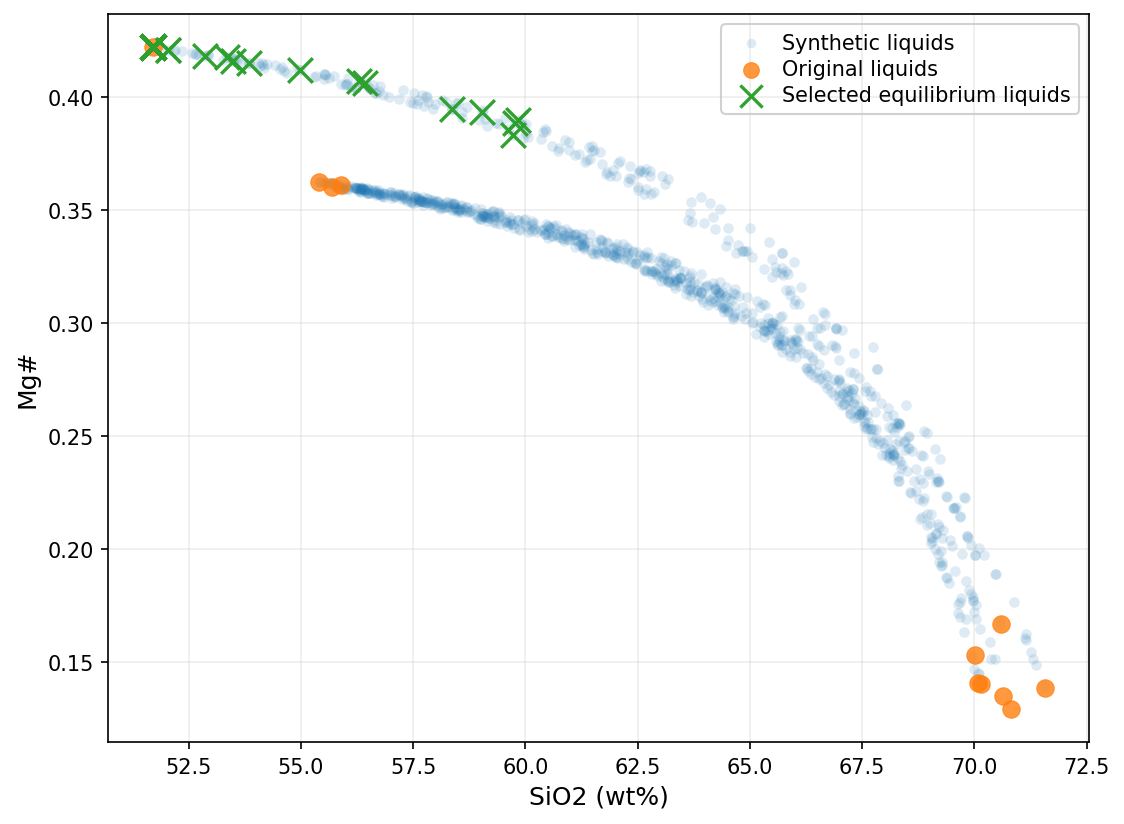

170

In [12]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd


# res_06 = pair_mineral_liquid_by_kd(
#     cpx_06_input, liq_2006[liq_cols],
#     kd=0.28, error=0.08,
#     interpolate_liq=True,
#     interp_mode="between",
#     n_synth=1000,
#     random_state=42
# )
res_06 = pair_mineral_liquid_by_kd(
    X_mine=cpx_06_input,
    X_liq=liq_2006[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2006[liq_2006['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2006[liq_2006['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)

paired_cpx_06, paired_liq_06 = res_06.cleaned_minerals, res_06.cleaned_liquids
paired_cpx_06_pass = paired_cpx_06[res_06.pairs_pass_mask].reset_index(drop=True)
paired_liq_06_pass = paired_liq_06[res_06.pairs_pass_mask].reset_index(drop=True)


len(paired_cpx_06_pass)

In [13]:
# kd range 
res_06.pairs["kd_value"].describe()

count    170.000000
mean       0.243706
std        0.019185
min        0.200200
25%        0.230167
50%        0.240439
75%        0.254976
max        0.281399
Name: kd_value, dtype: float64

In [14]:
res_06.pairs

,mine__Sample_id,mine__Eruption,mine__Source,mine__Rim/core,mine__SiO2,mine__TiO2,mine__Al2O3,mine__FeO,mine__MnO,mine__MgO,...,liq__liq__mix_f,liq__liq__endmember1_idx,liq__liq__endmember2_idx,mine__pair_mine_id,liq__pair_liq_id,mine__pair_row_idx,liq__pair_row_idx,kd_value,kd_error,if_pass_test
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,...,NaN,NaN,NaN,0,10,0,10,0.257238,0.022762,True
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,...,NaN,NaN,NaN,1,10,1,10,0.268478,0.011522,True
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,...,0.938805,3.0,2.0,2,596,2,596,0.279919,0.000081,True
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,...,0.568834,3.0,6.0,3,807,3,807,0.280247,0.000247,True
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,...,0.743460,3.0,3.0,4,329,4,329,0.279487,0.000513,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Un 159 2006pair-clB-cpx-rim-W,2006,LI thesis,NaN,51.637700,0.359146,1.598750,8.708690,0.696622,15.158300,...,NaN,NaN,NaN,165,10,165,10,0.235435,0.044565,True
166,Un 160 2006pair-clB-cpx-CORE1,2006,LI thesis,NaN,51.437700,0.409381,1.926880,8.708280,0.615156,15.110400,...,NaN,NaN,NaN,166,10,166,10,0.236170,0.043830,True
167,Un 161 2006pair-clB-cpx-CORE2,2006,LI thesis,NaN,51.680400,0.338079,1.557080,9.108510,0.726193,14.964400,...,NaN,NaN,NaN,167,10,167,10,0.249434,0.030566,True
168,Un 163 2006pair-clB-cpx-99E,2006,LI thesis,NaN,51.210300,0.355892,1.568620,8.778750,0.705213,14.858700,...,NaN,NaN,NaN,168,10,168,10,0.242114,0.037886,True


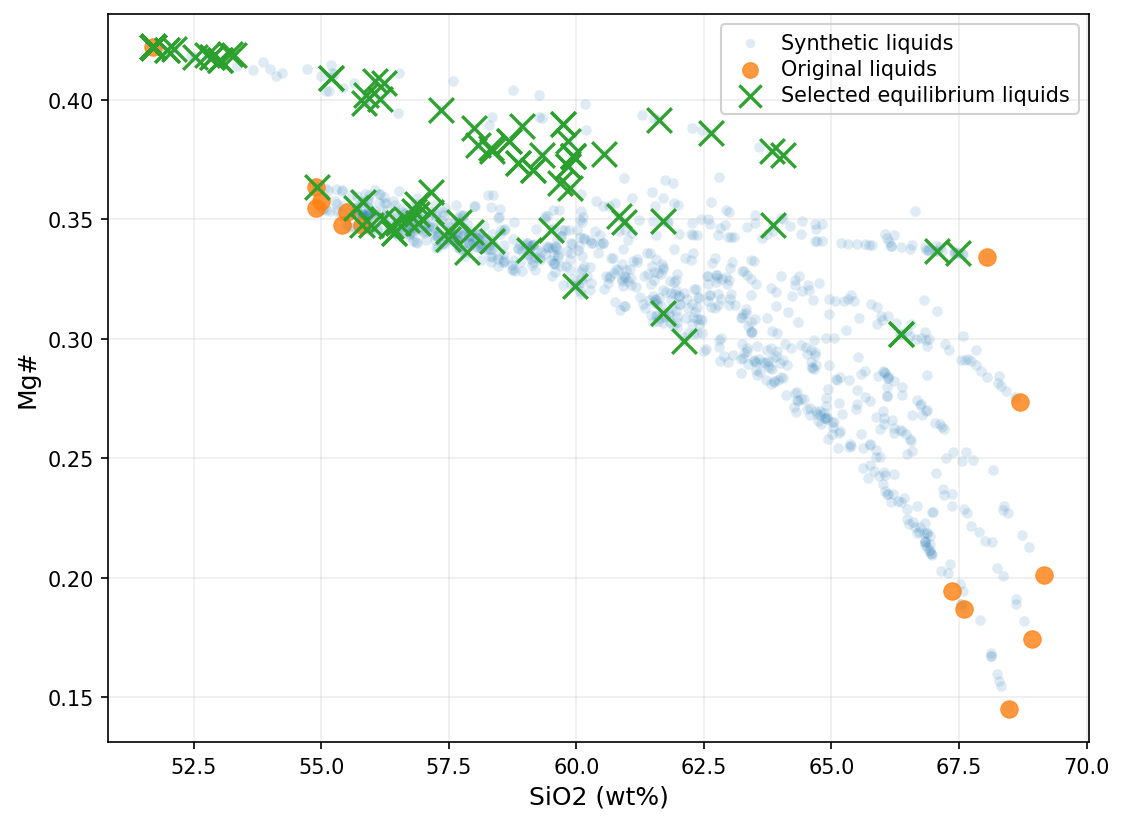

304

In [15]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd


# res_10 = pair_mineral_liquid_by_kd(
#     cpx_10_input, liq_2010[liq_cols],
#     kd=0.28, error=0.08,
#     interpolate_liq=True,
#     interp_mode="between",
#     n_synth=2000,
#     random_state=42
# )

res_10 = pair_mineral_liquid_by_kd(
    X_mine=cpx_10_input,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


## 4. Cpx-Liquid Thermobarometry

### Cpx-Liquid Setup

In [16]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_liq_pool = [model for model in P_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_P_06 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_P_10 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"

from aims4pt.reporting.excel import report_excel
report_excel(
    workflow_obj=workflow_cpx_liq_P_06,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_P_10,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_P_workflow_cpx_liq_P_0260604_1550.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_P_workflow_cpx_liq_P_0260604_1550.pkl


In [17]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_liq_pool = [model for model in T_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_T_06 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_T_10 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_liq_T_06,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_T_10,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_T_workflow_cpx_liq_T_0260604_1550.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_T_workflow_cpx_liq_T_0260604_1550.pkl


## 5. Cpx-Only Thermobarometry

### Cpx-Only Setup

In [18]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_only_pool = [model for model in P_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_P_06 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_P_10 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_P_06,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_P_10,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_P_workflow_cpx_only_P_0260604_1550.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_P_workflow_cpx_only_P_0260604_1550.pkl


In [19]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_only_pool = [model for model in T_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_T_06 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_T_10 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_T_06,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_T_10,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_T_workflow_cpx_only_T_0260604_1550.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_T_workflow_cpx_only_T_0260604_1550.pkl


## 6. Liquid Thermobarometry

### Data Preparation

In [20]:
glass_mineral  = {
    'ol': 0, #
    'opx': 1,
    'cpx': 1,
    'plag': 1,
    'amph': 1,
    'ox': 1,
    'bt': 0, #
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

whole_rock_mineral_2  = {
    'ol': 1,
    'opx': 1,
    'cpx': 1,
    'plag': 0,
    'amph': 0,
    'ox': 0,
    'bt': 0,
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

glass_mineral_df = pd.DataFrame([glass_mineral])
whole_rock_mineral_df_2 = pd.DataFrame([whole_rock_mineral_2])  


# liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
# liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)
liq_2006_glass = liq_2006[liq_2006["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2006_bulk = liq_2006[liq_2006["glass/bulk"]=="bulk"].reset_index(drop=True)
liq_2010_glass = liq_2010[liq_2010["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2010_bulk = liq_2010[liq_2010["glass/bulk"]=="bulk"].reset_index(drop=True)



In [21]:
from aims4pt.model_tools.local_models.WandB24_melt import WandB24_melt


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


### Glass Calculations

In [22]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",4) # 4 is the maximum
P_06_glass = P_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))

P_06_glass

0    2.571405
1    2.617135
2    2.597763
3    2.613756
4    2.385761
5    2.834220
6    2.701609
Name: P_kbar, dtype: float64

In [23]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_glass = P_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))

P_10_glass

0    3.624881
1    4.176075
2    3.883335
3    4.475628
4    3.583497
5    4.521359
6    4.835092
Name: P_kbar, dtype: float64

In [24]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 4)
T_06_glass = T_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))
T_06_glass

0    896.734320
1    895.690263
2    900.823777
3    887.202860
4    912.499878
5    890.807947
6    933.464901
Name: T_C, dtype: float64

In [25]:
T_10_glass = T_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))
T_10_glass

0    908.453739
1    944.435455
2    905.130439
3    939.026039
4    940.386646
5    928.743372
6    964.146544
Name: T_C, dtype: float64

### Whole-Rock Calculations

In [26]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",3)
P_06_bulk = P_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))

P_06_bulk

0    6.282600
1    6.306187
2    6.437876
3    8.125607
Name: P_kbar, dtype: float64

In [27]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_bulk = P_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))

P_10_bulk

0    6.530688
1    6.752381
2    6.587118
3    6.815809
4    6.808471
5    6.788134
6    8.125607
Name: P_kbar, dtype: float64

In [28]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 3)
T_06_bulk = T_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))
T_06_bulk

0    1055.818273
1    1053.651935
2    1063.067838
3    1098.733966
Name: T_C, dtype: float64

In [29]:
T_10_bulk = T_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))
T_10_bulk

0    1061.506121
1    1066.706402
2    1065.909294
3    1077.922585
4    1073.216512
5    1073.105220
6    1098.733966
Name: T_C, dtype: float64

## 7. Merapi compositions comparison with the independent dataset


In [40]:
from paper.scripts.figure_helpers import save_figure_pdf_png
from paper.scripts.merapi_helpers import plot_merapi_composition_comparison

import matplotlib.pyplot as plt


fig7, axes = plot_merapi_composition_comparison(
    unseen_experiments_df,
    paired_cpx_06_pass,
    paired_liq_06_pass,
    paired_cpx_10_pass,
    paired_liq_10_pass,
    liq_2006,
    liq_2010,
)

In [41]:
save_figure_pdf_png(fig7, IMAGES_DIR, "Fig_sX_Merapi_compositions_comparison_HPS_liq", dpi=600, bbox_inches="tight")


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_sX_Merapi_compositions_comparison_HPS_liq.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_sX_Merapi_compositions_comparison_HPS_liq.png'))

## 8. Merapi Plots and Comparison Figures

### Plotting Setup

In [31]:


df = pd.DataFrame({
    "min km": [1.5, 1.5,2, 0 , 10, 25],
    "max km": [2.5, 2.5,3, 4, 15, 45],
    "uncertainty": [1, 0.5, np.nan, 5, 5, 5],
})

from aims4pt.data_tools.crust import kbar_to_km_multilayer, km_to_kbar_multilayer
densities_kg_m3=[2242, 2900]
layer_boundaries_km=[10]

min_kbar = km_to_kbar_multilayer(df["min km"], densities_kg_m3, layer_boundaries_km)
max_kbar = km_to_kbar_multilayer(df["max km"], densities_kg_m3, layer_boundaries_km)
df["min kbar"] = min_kbar
df["max kbar"] = max_kbar
df

,min km,max km,uncertainty,min kbar,max kbar
0,1.5,2.5,1.0,0.329910,0.549851
1,1.5,2.5,0.5,0.329910,0.549851
2,2.0,3.0,NaN,0.439880,0.659821
3,0.0,4.0,5.0,0.000000,0.879761
4,10.0,15.0,5.0,2.199402,3.621852
5,25.0,45.0,5.0,6.466752,12.156552


In [ ]:

from aims4pt.model_tools.ModelManager import ModelManager
from aims4pt.visualization.thermobarometry_plot import (
    ThermobarometryWorkflowBundle,
    plot_ranked_thermobarometry_literature_comparison,
    plot_ranked_thermobarometry_summary,
)
from paper.scripts.figure_helpers import save_figure_pdf_png

T_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_T.xlsx")
P_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_P.xlsx")

P_lit_raw = pd.read_excel(P_LIT_PATH)
T_lit_raw = pd.read_excel(T_LIT_PATH)
P_lit_raw = P_lit_raw[P_lit_raw["plot"] == True].reset_index(drop=True)
T_lit_raw = T_lit_raw[T_lit_raw["plot"] == True].reset_index(drop=True)

densities_kg_m3 = [2242, 2900]
layer_boundaries_km = [10]


def _get_model_name(pool, T_P, cpx_only, aliases):
    """Return the model_name for the first matching alias."""
    for alias in aliases:
        model = ModelManager.get_model(
            pool,
            model_name=alias,
            T_P=T_P,
            cpx_only=cpx_only,
            exact=False,
            raise_if_empty=False,
        )
        if model is not None:
            return model.model_name
    raise ValueError(f"No model matched aliases: {aliases}")


def _get_model_names(pool, T_P, cpx_only, alias_groups):
    return [_get_model_name(pool, T_P, cpx_only, aliases) for aliases in alias_groups]


T_cols_liq = _get_model_names(
    T_model_pool,
    "T",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)
P_cols_liq = _get_model_names(
    P_model_pool,
    "P",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Neave & Putirka"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)

P_cols_only = _get_model_names(
    P_model_pool,
    "P",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Putirka, 2008 eq32d_T; eq32b_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)
T_cols_only = _get_model_names(
    T_model_pool,
    "T",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)

cpx_only = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_only_P_06,
    pressure_2010=workflow_cpx_only_P_10,
    temperature_2006=workflow_cpx_only_T_06,
    temperature_2010=workflow_cpx_only_T_10,
)

cpx_liq = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_liq_P_06,
    pressure_2010=workflow_cpx_liq_P_10,
    temperature_2006=workflow_cpx_liq_T_06,
    temperature_2010=workflow_cpx_liq_T_10,
)

liquid_results = {
    "P": {
        "2006": {"glass": P_06_glass, "bulk": P_06_bulk},
        "2010": {"glass": P_10_glass, "bulk": P_10_bulk},
    },
    "T": {
        "2006": {"glass": T_06_glass, "bulk": T_06_bulk},
        "2010": {"glass": T_10_glass, "bulk": T_10_bulk},
    },
}

# 2010 reservoir depth ranges. These values are explicit for easy later editing.
MERAPI_2010_RESERVOIR_BANDS = [
    {
        "label": "<4 km conduit",
        "min_depth_km": 0,
        "max_depth_km": 4,
        "color": "#EEDBB5",
        "alpha": 0.22,
    },
    {
        "label": "4-10 km upper-crustal",
        "min_depth_km": 4,
        "max_depth_km": 10,
        "color": "#DEBB7C",
        "alpha": 0.24,
        "hatch": "///",
        "edgecolor": "#938564",
        "linestyle": "--",
    },
    {
        "label": "13-19 km mid-crustal",
        "min_depth_km": 13,
        "max_depth_km": 19,
        "color": "#E9A382",
        "alpha": 0.22,
    },
    {
        "label": ">25 km lower-crustal",
        "min_depth_km": 25,
        "max_depth_km": 40,
        "color": "#E6827C",
        "alpha": 0.22,
    },
]

figs = plot_ranked_thermobarometry_summary(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    liquid_results=None,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    this_study_figsize=(23.0, 17.0),
    literature_figsize=(19.0, 17.0),
    show=False,
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
)


In [36]:
save_figure_pdf_png(figs["this_study"][0], IMAGES_DIR, "fig_sX_Merapi_P_T_HPS_liq_v2")
save_figure_pdf_png(figs["literature_comparison"][0], IMAGES_DIR, "fig_sX_Merapi_different_constraints_HPS_liq_v2")


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/fig_sX_Merapi_different_constraints_HPS_liq_v2.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/fig_sX_Merapi_different_constraints_HPS_liq_v2.png'))

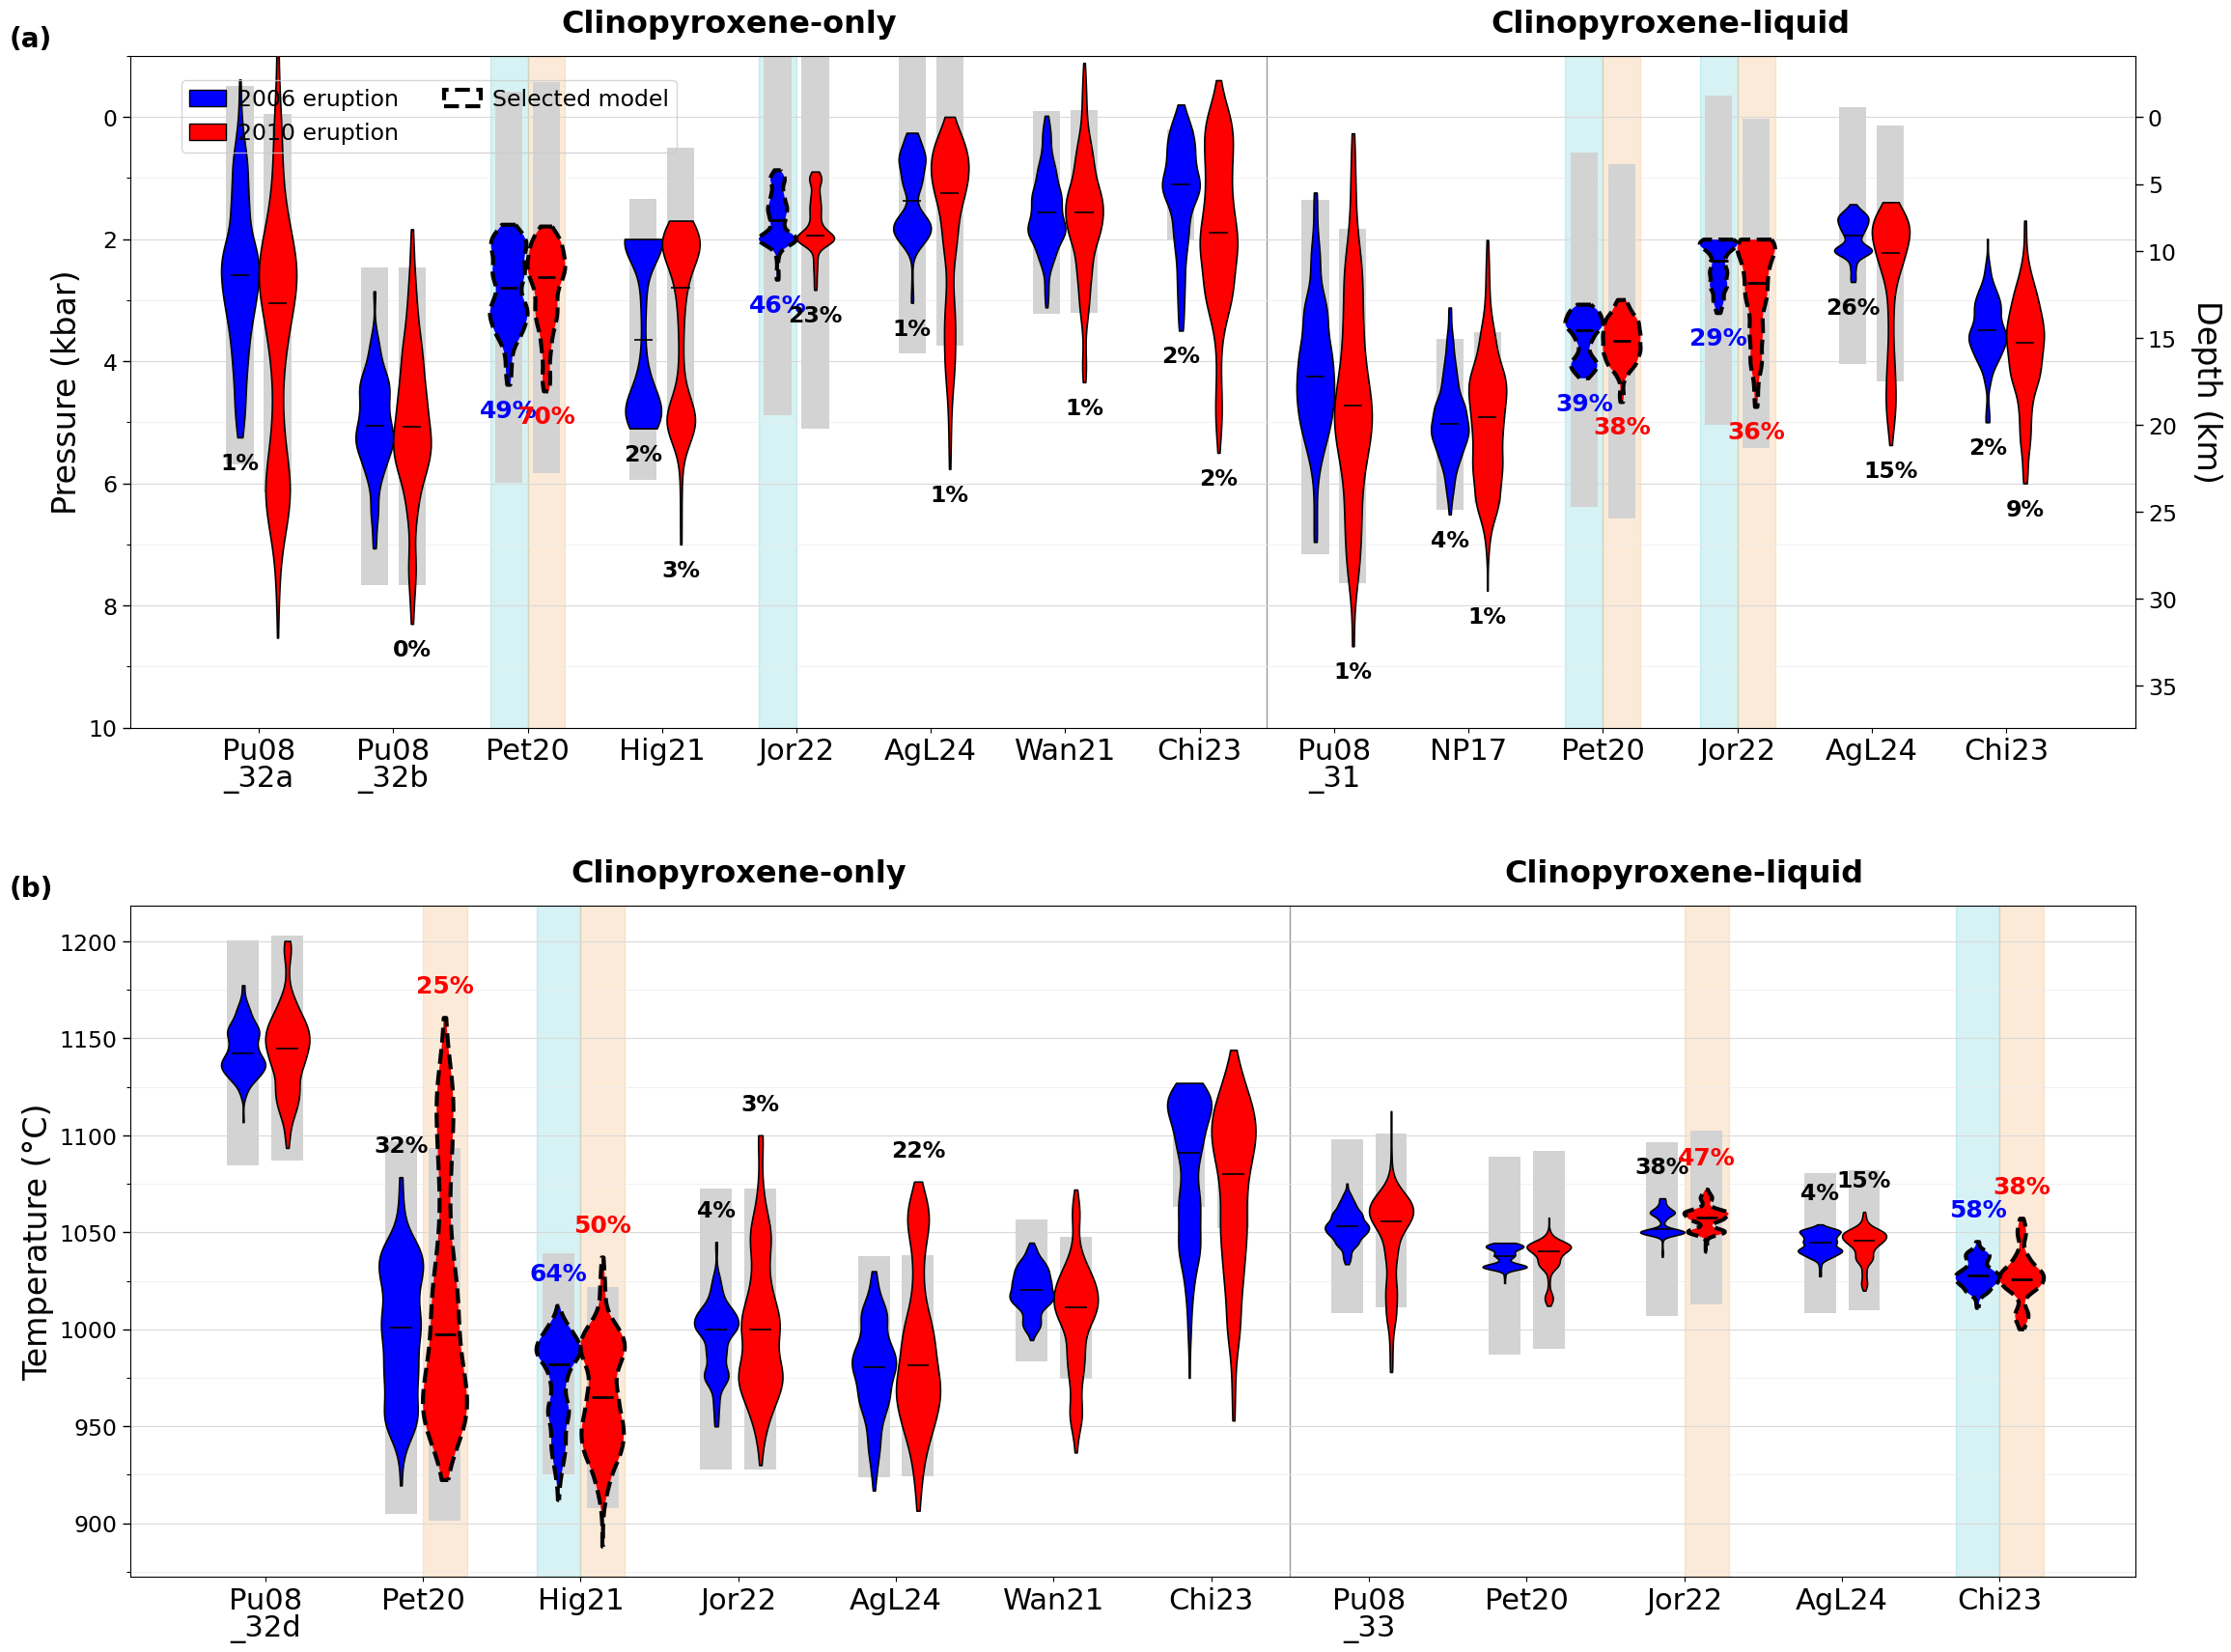

In [33]:
figs["this_study"][0]

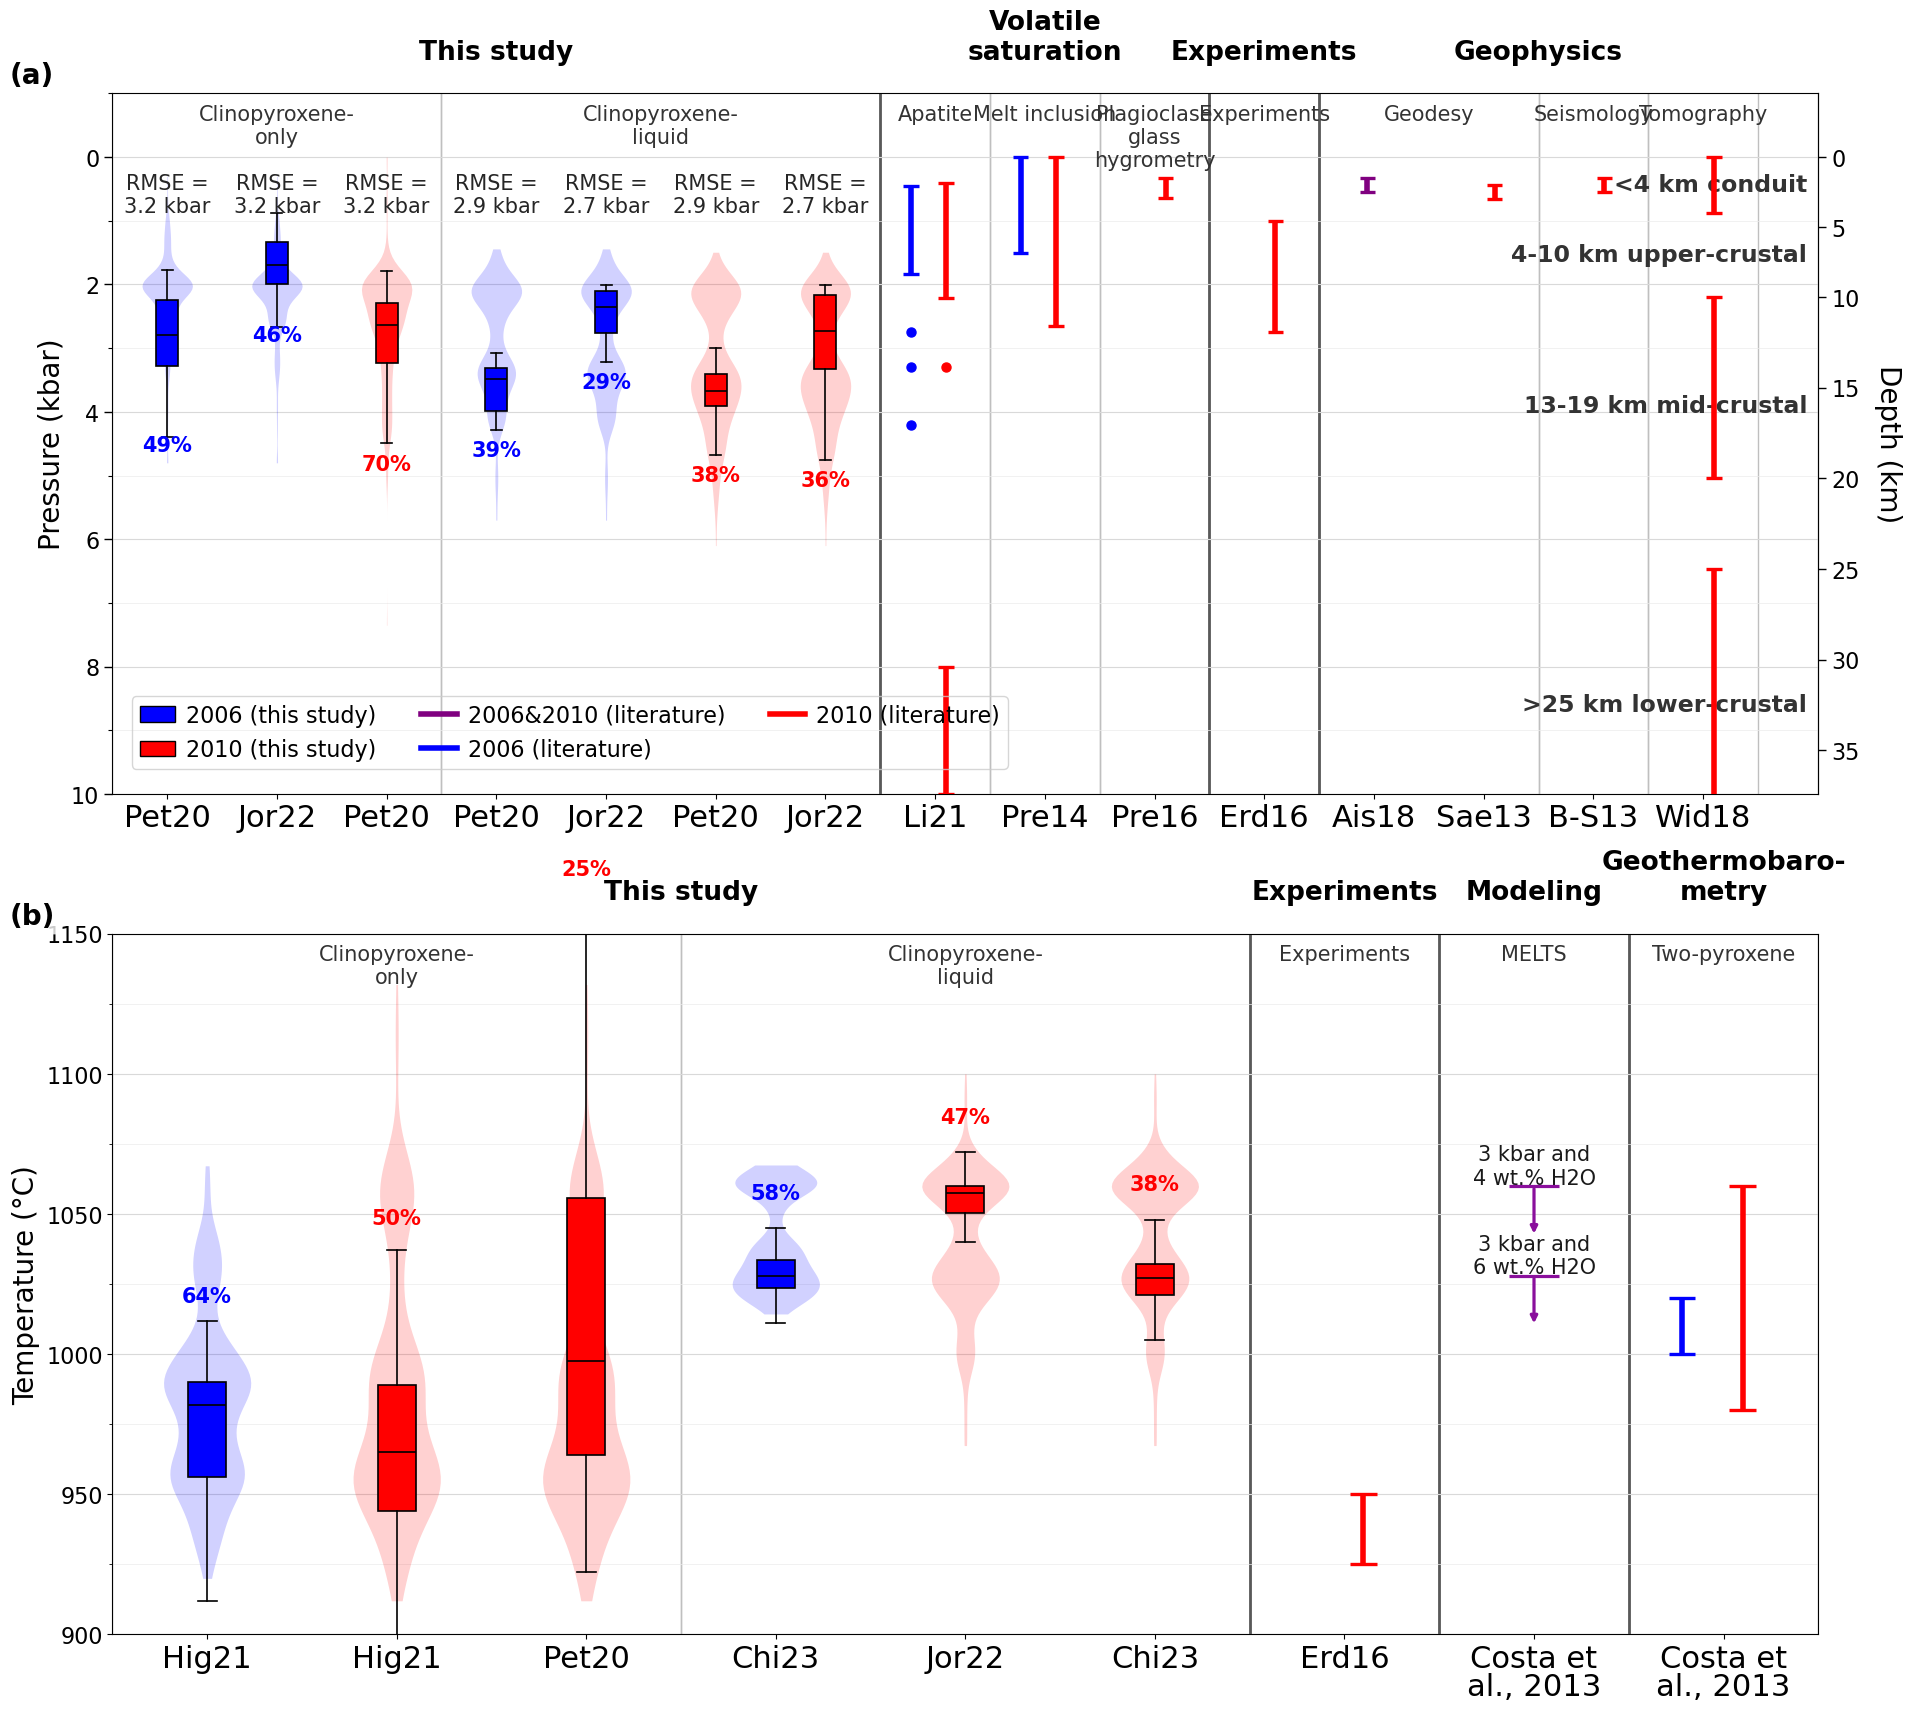

In [34]:
figs["literature_comparison"][0]

In [35]:

fig_s9, axes_s9 = plot_ranked_thermobarometry_literature_comparison(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=liquid_results,
    pressure_ylim=(-1, 10),
    temperature_ylim = (800, 1150),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    figsize=(20.0, 17.0),
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
)
# save_figure_pdf_png(
#     fig_s9,
#     IMAGES_DIR,
#     "fig_sX_Merapi_different_constraints_with_liquid_thermobarometer_HPS_liq",
# )

plt.show()


C:\Users\13493\AppData\Local\Temp\ipykernel_79024\3325495682.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
